<a href="https://colab.research.google.com/github/SalmaAllam8/Brazilian-E-Commerce/blob/main/Notebook/Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch --quiet

In [2]:
from transformers import pipeline

In [5]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [6]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

result = sentiment_pipeline("Produto excelente, chegou rápido e bem embalado!")
print(result)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': '5 stars', 'score': 0.8212166428565979}]


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [13]:
import pandas as pd
from tqdm.auto import tqdm


In [11]:
olist_order_reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")

In [14]:
reviews = olist_order_reviews['review_comment_message'].dropna()

results = []
batch_size = 32
for i in tqdm(range(0, len(reviews), batch_size)):
    batch = reviews.iloc[i:i+batch_size].tolist()
    results.extend(sentiment_pipeline(batch, truncation=True))



  0%|          | 0/1281 [00:00<?, ?it/s]

NameError: name 'map_sentiment' is not defined

In [17]:
def map_sentiment(label):
    stars = int(label[0])
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

In [18]:

df_sentiment = pd.DataFrame({
    'review': reviews.values,
    'label': [r['label'] for r in results],
    'score': [r['score'] for r in results]
})

In [19]:
df_sentiment['sentiment'] = df_sentiment['label'].apply(map_sentiment)

sentiment_pct = df_sentiment['sentiment'].value_counts(normalize=True) * 100
print(sentiment_pct)

sentiment
positive    52.995583
negative    37.935915
neutral      9.068502
Name: proportion, dtype: float64


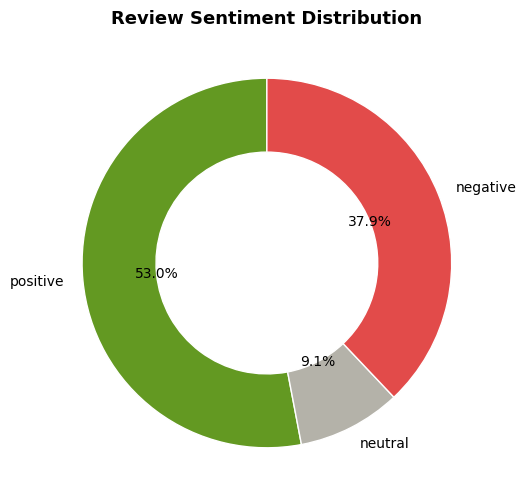

In [21]:
import matplotlib.pyplot as plt

colors = {'positive': '#639922', 'neutral': '#B4B2A9', 'negative': '#E24B4A'}
sentiment_order = ['positive', 'neutral', 'negative']
values = [sentiment_pct[s] for s in sentiment_order]
plot_colors = [colors[s] for s in sentiment_order]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    values, labels=sentiment_order, autopct='%1.1f%%',
    colors=plot_colors, startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)
ax.set_title('Review Sentiment Distribution', fontsize=13, fontweight='bold')
plt.show()

In [22]:
# Merge sentiment results back with the original review_score
df_check = olist_order_reviews.dropna(subset=['review_comment_message']).copy()
df_check['sentiment'] = df_sentiment['sentiment'].values  # same order/index as reviews

# Cross-tab: does predicted sentiment align with star rating?
comparison = pd.crosstab(df_check['review_score'], df_check['sentiment'], normalize='index') * 100
print(comparison.round(1))

sentiment     negative  neutral  positive
review_score                             
1                 91.6      3.7       4.8
2                 81.5     11.2       7.3
3                 56.3     21.5      22.3
4                 22.7     16.8      60.5
5                 11.8      6.8      81.4


In [23]:
!pip install wordcloud --quiet

In [24]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [25]:
# 1. Download emoji images to use as masks (Twemoji, hosted on GitHub)
thumbs_up_url = "https://raw.githubusercontent.com/twitter/twemoji/master/assets/72x72/1f44d.png"
thumbs_down_url = "https://raw.githubusercontent.com/twitter/twemoji/master/assets/72x72/1f44e.png"

def load_mask(url, size=(800, 800)):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGBA")

    # Place the emoji on a white background (wordcloud masks need white = "skip", non-white = "fill")
    background = Image.new("RGBA", img.size, (255, 255, 255, 255))
    combined = Image.alpha_composite(background, img).convert("RGB")
    combined = combined.resize(size)

    return np.array(combined)

mask_positive = load_mask(thumbs_up_url)
mask_negative = load_mask(thumbs_down_url)

In [26]:
# 2. Prepare positive and negative review text
positive_text = ' '.join(df_sentiment[df_sentiment['sentiment'] == 'positive']['review'].astype(str))
negative_text = ' '.join(df_sentiment[df_sentiment['sentiment'] == 'negative']['review'].astype(str))

# Portuguese stopwords (WordCloud's built-in STOPWORDS is English-only, so add Portuguese ones)
portuguese_stopwords = set(STOPWORDS)
portuguese_stopwords.update([
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'não',
    'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas',
    'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando',
    'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela',
    'até', 'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos',
    'ter', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você',
    'produto', 'entrega', 'prazo'  # domain-specific filler words worth excluding
])

In [29]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zà-ÿ\s]', '', text)  # keep only letters (including accented) and spaces
    return text

positive_text = clean_text(positive_text)
negative_text = clean_text(negative_text)

In [30]:
# 3. Generate word clouds
wc_positive = WordCloud(
    width=800, height=800,
    background_color='white',
    mask=mask_positive,
    stopwords=portuguese_stopwords,
    colormap='Greens',
    contour_width=1,
    contour_color='darkgreen'
).generate(positive_text)

wc_negative = WordCloud(
    width=800, height=800,
    background_color='white',
    mask=mask_negative,
    stopwords=portuguese_stopwords,
    colormap='Reds',
    contour_width=1,
    contour_color='darkred'
).generate(negative_text)

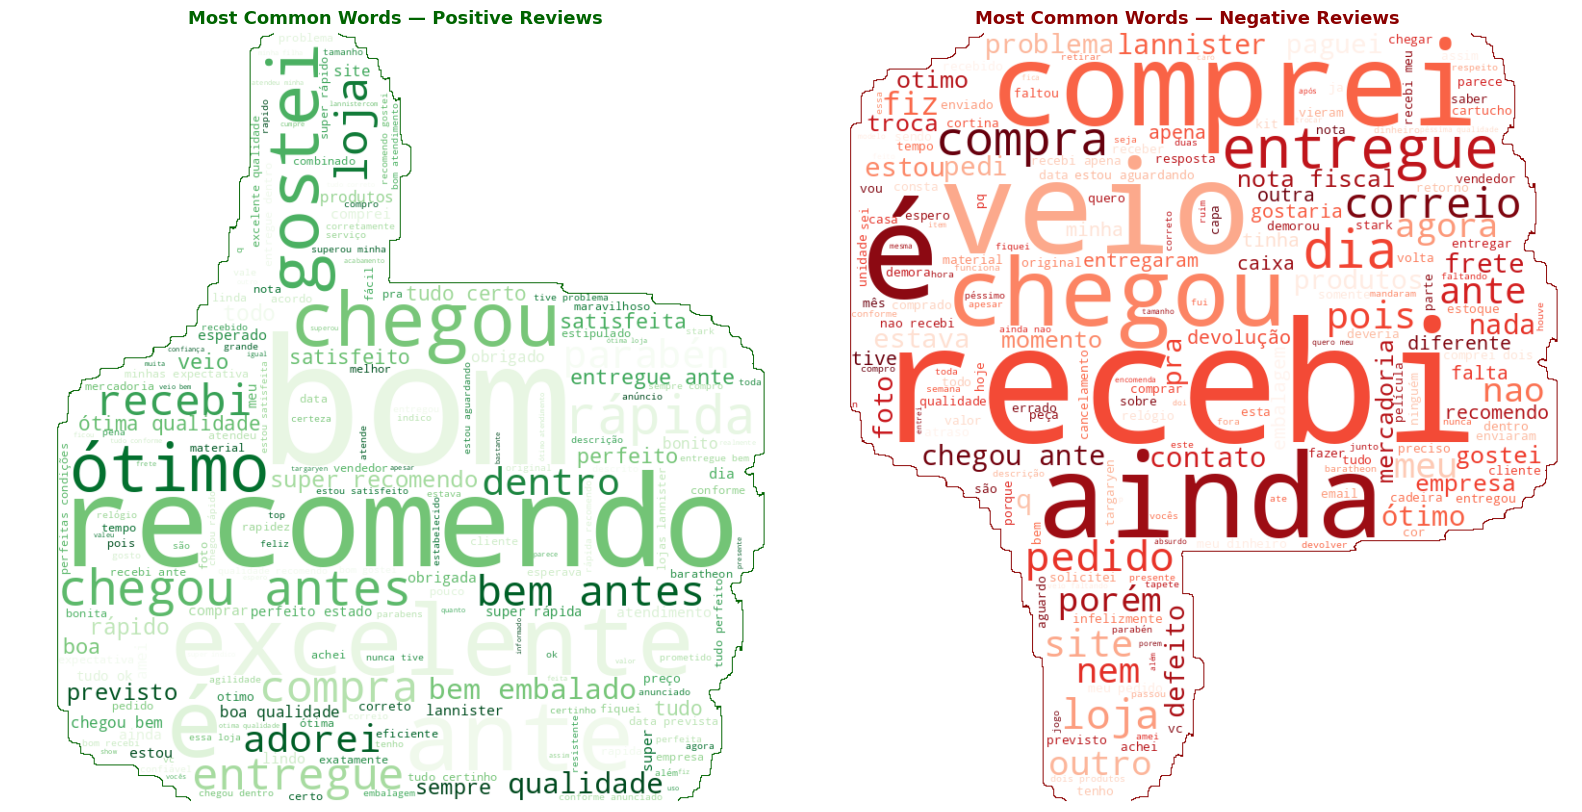

In [31]:
# 4. Plot both side by side
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].imshow(wc_positive, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title('Most Common Words — Positive Reviews', fontsize=13, fontweight='bold', color='darkgreen')

axs[1].imshow(wc_negative, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title('Most Common Words — Negative Reviews', fontsize=13, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()